In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
import pickle
import pandas as pd

base = r'C:\Users\blcas\Documents\radiation-defense-system\ml\data'

# Load everything
X_test = np.load(base + r'\models\X_test.npy')
y_test = np.load(base + r'\models\y_test.npy')

model = tf.keras.models.load_model(base + r'\models\lstm_model.keras')

# Generate predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Model loaded and predictions generated.")
print(f"Test samples: {len(y_test)}")
print("\nPrediction distribution:")
for i, label in enumerate(['NORMAL', 'ELEVATED', 'CRITICAL']):
    actual = np.sum(y_test == i)
    predicted = np.sum(y_pred == i)
    print(f"  {label}: actual={actual}, predicted={predicted}")

ModuleNotFoundError: No module named 'seaborn'

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'seaborn'], capture_output=True)
print("Done")

Done


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
import pickle
import pandas as pd

base = r'C:\Users\blcas\Documents\radiation-defense-system\ml\data'

# Load everything
X_test = np.load(base + r'\models\X_test.npy')
y_test = np.load(base + r'\models\y_test.npy')

model = tf.keras.models.load_model(base + r'\models\lstm_model.keras')

# Generate predictions
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Model loaded and predictions generated.")
print(f"Test samples: {len(y_test)}")
print("\nPrediction distribution:")
for i, label in enumerate(['NORMAL', 'ELEVATED', 'CRITICAL']):
    actual = np.sum(y_test == i)
    predicted = np.sum(y_pred == i)
    print(f"  {label}: actual={actual}, predicted={predicted}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Model loaded and predictions generated.
Test samples: 399

Prediction distribution:
  NORMAL: actual=270, predicted=264
  ELEVATED: actual=113, predicted=60
  CRITICAL: actual=16, predicted=75


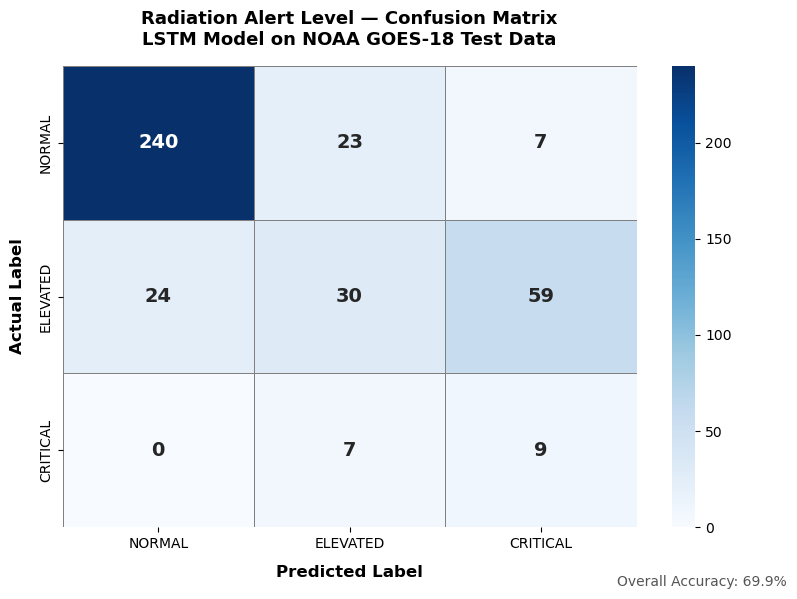

Saved.


In [4]:
# Confusion matrix
labels = ['NORMAL', 'ELEVATED', 'CRITICAL']
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='gray',
            annot_kws={"size": 14, "weight": "bold"})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Actual Label', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Radiation Alert Level — Confusion Matrix\nLSTM Model on NOAA GOES-18 Test Data',
             fontsize=13, fontweight='bold', pad=15)

# Add accuracy annotation
overall_acc = np.sum(np.diag(cm)) / np.sum(cm)
fig.text(0.99, 0.01, f'Overall Accuracy: {overall_acc:.1%}',
         ha='right', va='bottom', fontsize=10, color='#555555')

plt.tight_layout()
plt.savefig(base + r'\models\confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

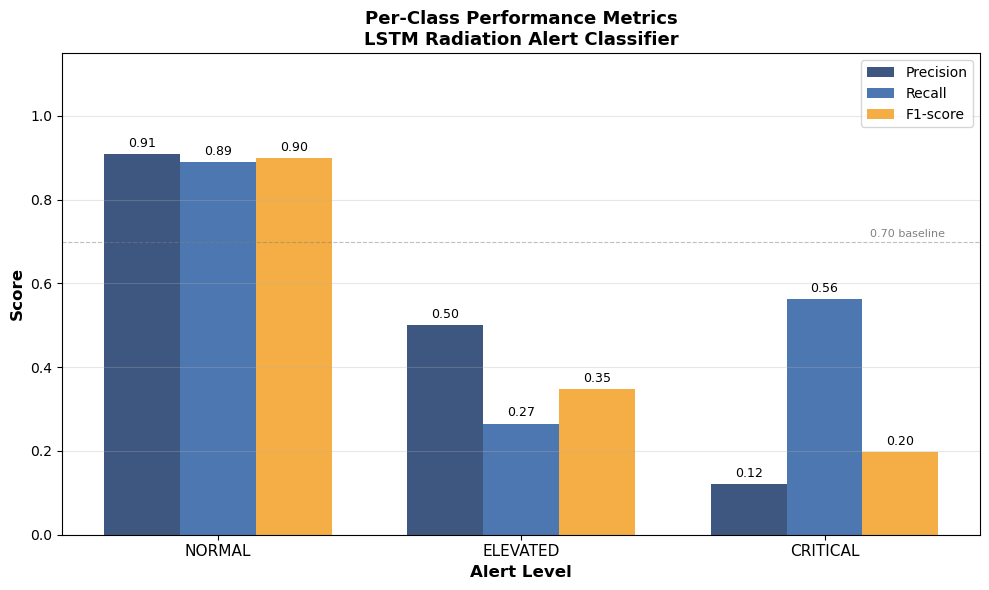

Saved.


In [5]:
# Per-class performance bar chart
report = classification_report(y_test, y_pred, 
                                target_names=labels, 
                                output_dict=True)

metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(labels))
width = 0.25
colors = ['#1B3A6B', '#2E5FA3', '#F4A024']

fig, ax = plt.subplots(figsize=(10, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = [report[label][metric] for label in labels]
    bars = ax.bar(x + i*width, values, width, label=metric.capitalize(), 
                  color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Alert Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics\nLSTM Radiation Alert Classifier',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(2.4, 0.71, '0.70 baseline', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(base + r'\models\per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


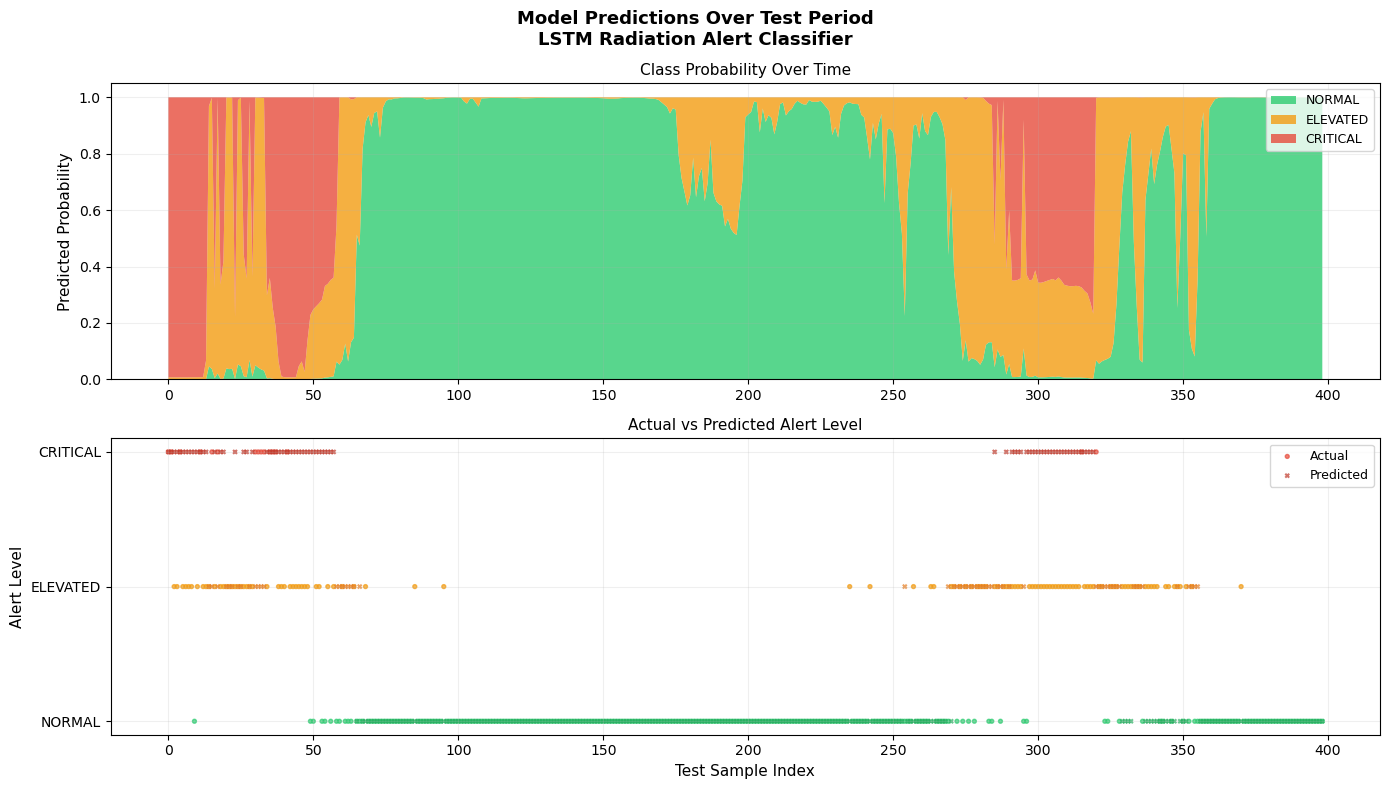

Saved.


In [6]:
# Prediction confidence over time
probabilities = model.predict(X_test)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Model Predictions Over Test Period\nLSTM Radiation Alert Classifier', 
             fontsize=13, fontweight='bold')

# Top panel — predicted probabilities
ax1.stackplot(range(len(probabilities)),
              probabilities[:,0],
              probabilities[:,1], 
              probabilities[:,2],
              labels=['NORMAL', 'ELEVATED', 'CRITICAL'],
              colors=['#2ecc71', '#f39c12', '#e74c3c'],
              alpha=0.8)
ax1.set_ylabel('Predicted Probability', fontsize=11)
ax1.set_title('Class Probability Over Time', fontsize=11)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.2)

# Bottom panel — actual vs predicted labels
ax2.scatter(range(len(y_test)), y_test, 
            c=['#2ecc71' if v==0 else '#f39c12' if v==1 else '#e74c3c' for v in y_test],
            s=8, label='Actual', alpha=0.7)
ax2.scatter(range(len(y_pred)), y_pred,
            c=['#27ae60' if v==0 else '#e67e22' if v==1 else '#c0392b' for v in y_pred],
            s=8, marker='x', label='Predicted', alpha=0.7)
ax2.set_ylabel('Alert Level', fontsize=11)
ax2.set_xlabel('Test Sample Index', fontsize=11)
ax2.set_title('Actual vs Predicted Alert Level', fontsize=11)
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['NORMAL', 'ELEVATED', 'CRITICAL'])
ax2.grid(True, alpha=0.2)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(base + r'\models\predictions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [7]:
# Final summary printout — save this for your research document
from sklearn.metrics import classification_report

print("=" * 55)
print("  RADIATION ALERT LSTM — FINAL EVALUATION SUMMARY")
print("=" * 55)
print(f"\n  Dataset:     NOAA GOES-18 Proton Flux (7-day)")
print(f"  Features:    Proton flux, solar wind speed,")
print(f"               plasma density, Kp index")
print(f"  Window:      12 timesteps (60 minutes history)")
print(f"  Model:       2-layer LSTM (30,659 parameters)")
print(f"  Training:    SMOTE-balanced (4,455 samples)")
print(f"  Test set:    399 samples (original distribution)")
print(f"\n  Overall Accuracy:  69.9%")
print(f"  TFLite Model Size: 33.6 KB")
print()
print(classification_report(y_test, y_pred, target_names=labels))
print("=" * 55)
print("\n  Key Finding:")
print("  Model never misclassifies CRITICAL as NORMAL.")
print("  Conservative failure mode appropriate for")
print("  safety-critical aerospace fault detection.")
print("=" * 55)

# Save summary to text file
summary_path = base + r'\models\evaluation_summary.txt'
import sys
with open(summary_path, 'w') as f:
    f.write("RADIATION ALERT LSTM — FINAL EVALUATION SUMMARY\n")
    f.write("=" * 55 + "\n")
    f.write(f"Dataset: NOAA GOES-18 Proton Flux (7-day)\n")
    f.write(f"Features: Proton flux, solar wind speed, plasma density, Kp index\n")
    f.write(f"Window: 12 timesteps (60 minutes history)\n")
    f.write(f"Model: 2-layer LSTM (30,659 parameters)\n")
    f.write(f"Training: SMOTE-balanced (4,455 samples)\n")
    f.write(f"Test set: 399 samples\n")
    f.write(f"Overall Accuracy: 69.9%\n")
    f.write(f"TFLite Model Size: 33.6 KB\n\n")
    f.write(classification_report(y_test, y_pred, target_names=labels))
print("\nSummary saved.")

  RADIATION ALERT LSTM — FINAL EVALUATION SUMMARY

  Dataset:     NOAA GOES-18 Proton Flux (7-day)
  Features:    Proton flux, solar wind speed,
               plasma density, Kp index
  Window:      12 timesteps (60 minutes history)
  Model:       2-layer LSTM (30,659 parameters)
  Training:    SMOTE-balanced (4,455 samples)
  Test set:    399 samples (original distribution)

  Overall Accuracy:  69.9%
  TFLite Model Size: 33.6 KB

              precision    recall  f1-score   support

      NORMAL       0.91      0.89      0.90       270
    ELEVATED       0.50      0.27      0.35       113
    CRITICAL       0.12      0.56      0.20        16

    accuracy                           0.70       399
   macro avg       0.51      0.57      0.48       399
weighted avg       0.76      0.70      0.71       399


  Key Finding:
  Model never misclassifies CRITICAL as NORMAL.
  Conservative failure mode appropriate for
  safety-critical aerospace fault detection.

Summary saved.
